In [1]:
from lasy.laser import Laser
from lasy.profiles.gaussian_profile import GaussianProfile
from lasy.optical_elements import ParabolicMirror

import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c

import prepareLasyLaser as pll

dim = "rt"

In [2]:
l_w = 10.54e-7
f = 7e-2
w = 1e-3
tau = 1.5e-14
E = 6.2
des_dt = 1.39e-16 # PIConGPU Standardwert
w0 = f * l_w / w / np.pi
print("w0 =", w0)
print("w/w0 =",w/w0)

p_per_r = 2
picpoints_per_p = 2
print("points in file:", int(1024/picpoints_per_p))
spacing = 0.1772e-6 * p_per_r * 2 # PIConGPU Standardwert
npoints = (int(5*w/spacing), 800)
print("approximate file size:", int(1024/picpoints_per_p)*int(1024/picpoints_per_p)/1024*4+100, "MB")

hi = (5*w, 9*tau)
lo = (0., -15*tau)
offset_frac = hi[1]/2 / (hi[1]-lo[1])
print(offset_frac)
print(npoints)

w0 = 2.3484903402640077e-05
w/w0 = 42.580545589452335
points in file: 512
approximate file size: 1124.0 MB
0.18749999999999997
(7054, 800)


In [3]:
profile = GaussianProfile(l_w, (1,0), E, w, tau, 0.0)
laser = Laser(dim, lo, hi, npoints, profile)

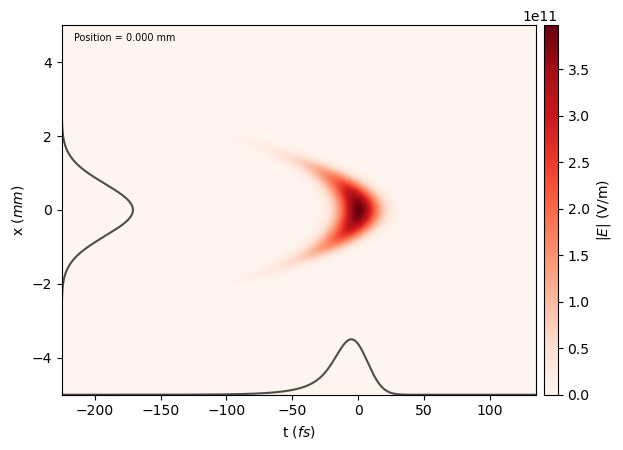

In [4]:
parabola = ParabolicMirror(f)
laser.apply_optics(parabola)
laser.show()

0.0683560567618152
time steps to focus: 39450.39128073632
Available backends are: NP
NP is chosen


  0%|          | 00:00<? [?it/s]

Extracting full field
Offsetting by 18.74 percent of the original field


  0%|          | 00:00<? [?it/s]

Displaying


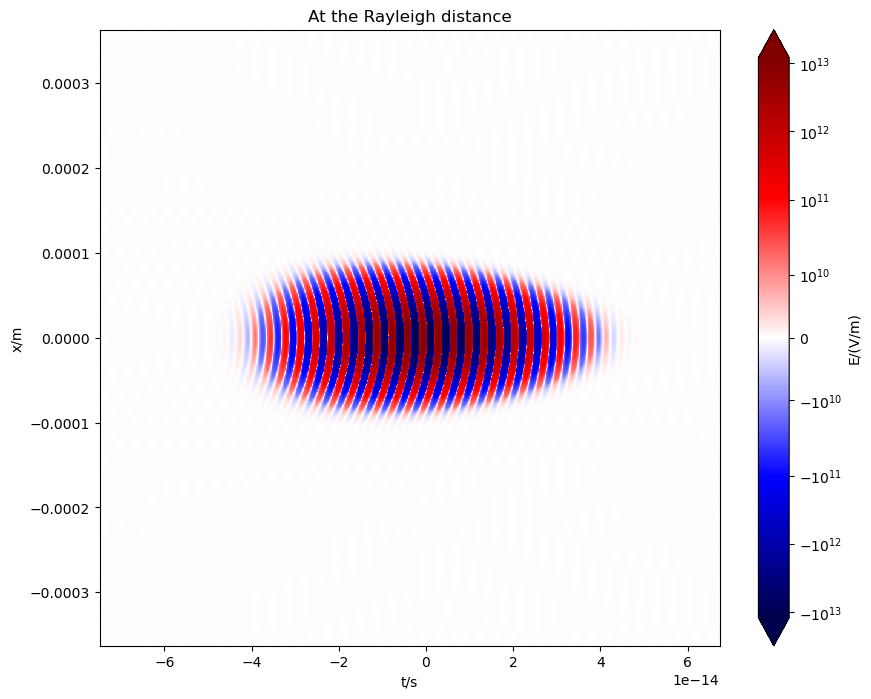

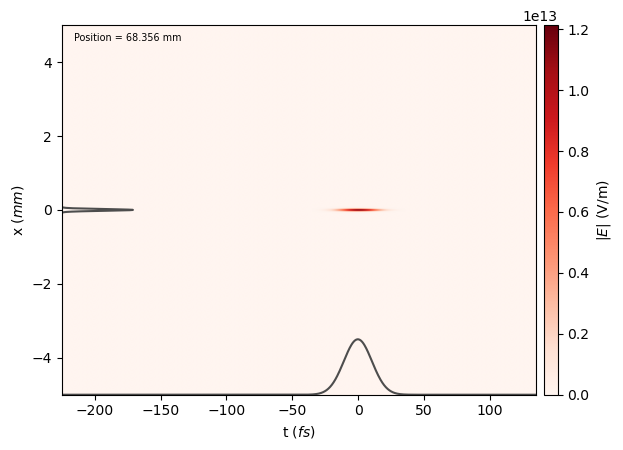

In [5]:
zr = np.pi * w0**2 / l_w
l = f - zr
print(l)
print("time steps to focus:", zr / c / des_dt)
laser.propagate(l)
# The loading bar will only go to about 63 % in this case. That is because the internal algorithm, angular sectrum propagation, loops over frequencies and draws their square roots.
# To avoid having to deal with complex numbers and because those make evanecent waves it skips loops where those frequencies get negative so they dont contribute to the loading bar.
# To what number it will get depends on the specific setup (hi, lo and npoints and the wavelength mostly). Importantly, it does not depend on the propagation distance.
pll.show_field(laser, Nt=1024, Nr=512, offset_frac=offset_frac, forced_dt=des_dt, linthresh_frac=0.001, title="At the Rayleigh distance")
laser.show()

In [6]:
from lasy.utils.laser_utils import get_w0
print("w = ", get_w0(laser.grid, laser.dim))

w =  3.2777043815964476e-05


extracting full field...


  0%|          | 00:00<? [?it/s]

Offsetting by 18.74 percent of the original field


  0%|          | 00:00<? [?it/s]

saving...
transposing
Data type: float32
flushing


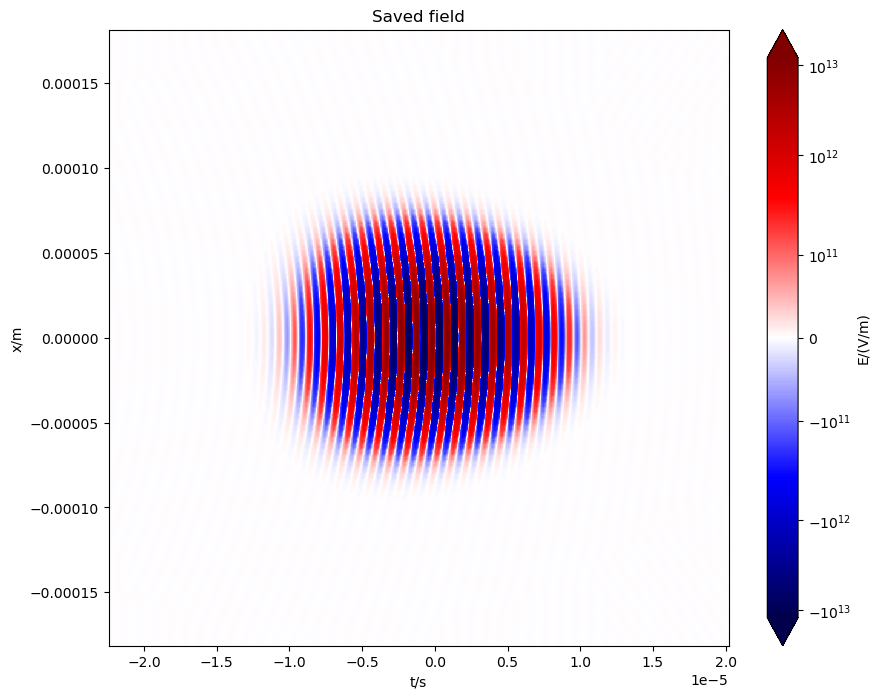

done


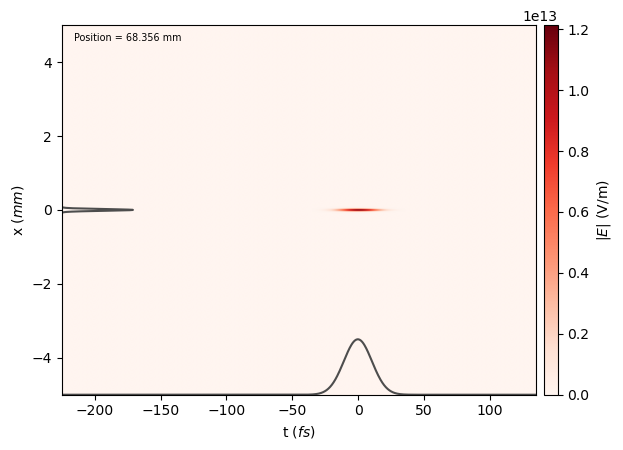

In [7]:
pll.laser_to_openPMD(laser, "parabol", Nt=1024, Nx=int(1024/picpoints_per_p), Ny=int(1024/picpoints_per_p),
                            points_between_r=p_per_r, forced_dt=des_dt, offset_frac=offset_frac, file_format="bp", data_step=picpoints_per_p, show=True)
laser.show()

  0%|          | 00:00<? [?it/s]

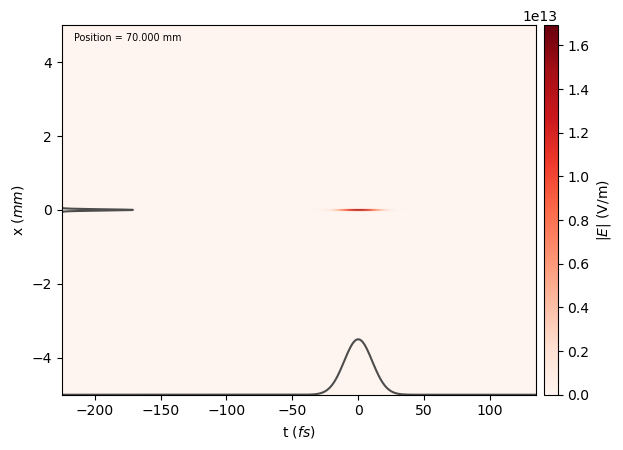

In [8]:
laser.propagate(zr)
laser.show()

Extracting full field
Offsetting by 18.74 percent of the original field


  0%|          | 00:00<? [?it/s]

Displaying


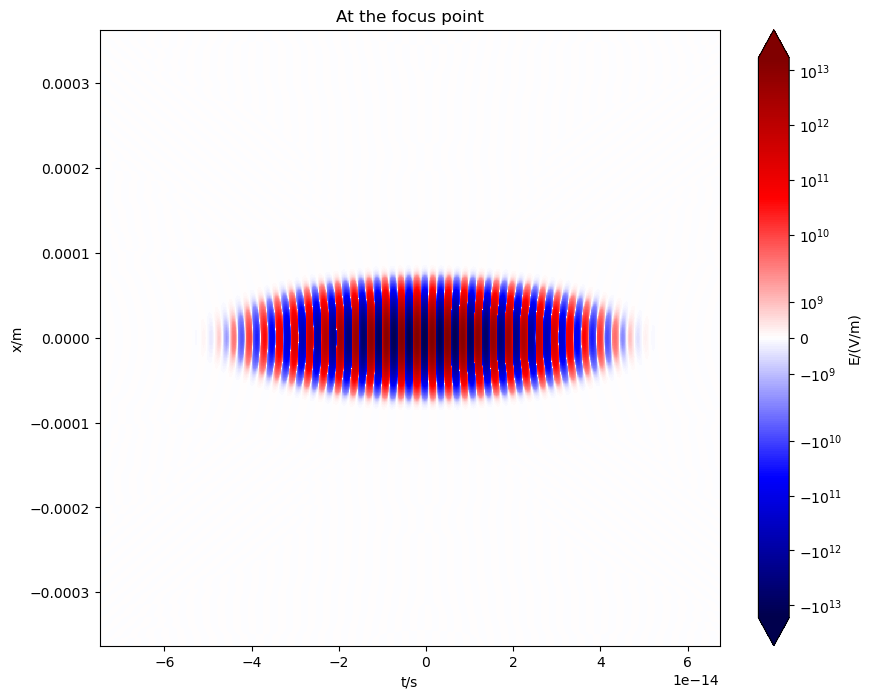

In [9]:
pll.show_field(laser, Nt=1024, Nr=512, offset_frac=offset_frac, forced_dt=des_dt, linthresh_frac=0.0001, title="At the focus point")

In [10]:
print("w = ", get_w0(laser.grid, laser.dim))
print("w0 should be:", w0)

w =  2.350558454857722e-05
w0 should be: 2.3484903402640077e-05


  0%|          | 00:00<? [?it/s]

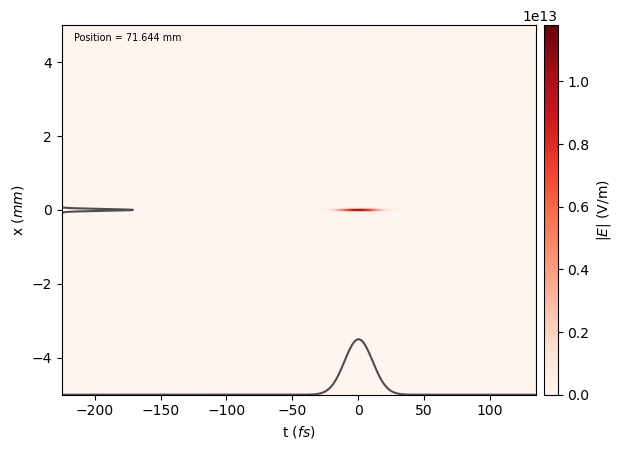

In [11]:
laser.propagate(zr)
laser.show()

Extracting full field
Offsetting by 18.74 percent of the original field


  0%|          | 00:00<? [?it/s]

Displaying


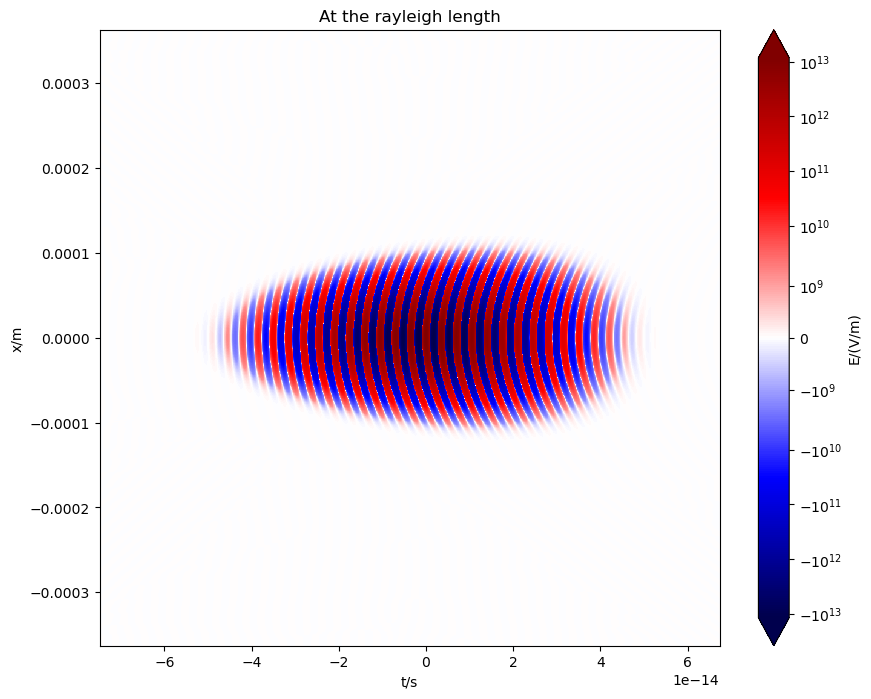

In [12]:
pll.show_field(laser, Nt=1024, Nr=512, offset_frac=offset_frac, forced_dt=des_dt, linthresh_frac=0.0001, title="At the rayleigh length")